# 02 - Generate One AnnData per CNV Template

This notebook takes the template definitions generated in `01_Define_CNV_templates` and creates one full-gene simulated `AnnData` per template.

Each output dataset keeps all genes and contains the simulation layers needed downstream (e.g. `CNV_simulated`, `CNV_GT`, `counts`).

In [1]:
from pathlib import Path
import json
import pandas as pd
import scanpy as sc
import numpy as np
import sys
sys.path.append("/home/augusta/storage3/augusta/insituCNV/InSituCNV")
import insitucnv as icv

try:
    import yaml
except ImportError:
    yaml = None

In [3]:
ROOT = Path('/home/augusta/storage3/augusta/insituCNV/InSituCNV/Evaluate_technical_constrains')
TEMPLATES_MANIFEST = ROOT / 'manifests' / 'templates.csv'
CONFIG_PATH = ROOT / 'config' / 'technical_grid.yaml'

# Preferred base file from this workflow; fallback to the same base used in Figure2
BASE_CANDIDATES = [
    ROOT / 'data' / 'intermediate' / 'lung_organoids_base_for_templates.h5ad',
    Path('/home/augusta/storage3/augusta/insituCNV/data/simulated_CNV_data/lung_organoids_cnvclust.h5ad'),
]

BASE_ADATA = None
for p in BASE_CANDIDATES:
    if p.exists():
        BASE_ADATA = p
        break

if BASE_ADATA is None:
    raise FileNotFoundError(f'No base AnnData found in candidates: {BASE_CANDIDATES}')

OUT_DIR = ROOT / 'data' / 'intermediate' / 'template_adatas'
OUT_DIR.mkdir(parents=True, exist_ok=True)

INDEX_OUT = ROOT / 'manifests' / 'template_adata_index.csv'

assert TEMPLATES_MANIFEST.exists(), f'Missing templates manifest: {TEMPLATES_MANIFEST}'

In [4]:
# Load simulation defaults from config if available
defaults = {
    'alpha': 6,
    'cell_type_reference_key': 'cell_type',
    'cell_type_cnv': 'secretory cell',
}

if CONFIG_PATH.exists() and yaml is not None:
    with open(CONFIG_PATH) as f:
        cfg = yaml.safe_load(f)
    sim_cfg = cfg.get('simulation', {})
    defaults.update({
        'alpha': sim_cfg.get('alpha', defaults['alpha']),
        'cell_type_reference_key': sim_cfg.get('cell_type_reference_key', defaults['cell_type_reference_key']),
        'cell_type_cnv': sim_cfg.get('cell_type_cnv', defaults['cell_type_cnv']),
    })

defaults

{'alpha': 6,
 'cell_type_reference_key': 'cell_type',
 'cell_type_cnv': 'secretory cell'}

In [5]:
templates_df = pd.read_csv(TEMPLATES_MANIFEST)
templates_df

,template_id,template_name,source_cnv_csv,source_subclone_json,seed,min_size_bp,max_size_bp,n_A_unique,n_B_unique,n_C_unique,n_total_cnv_genes,n_trunk,trunk_genes,p_N,p_A,p_B,p_C
0,T01,template_t01,/home/augusta/storage3/augusta/insituCNV/InSit...,/home/augusta/storage3/augusta/insituCNV/InSit...,1001,10000000,20000000,0,3,3,9,3,CDKN2A;MET;MYC,0.358766,0.012329,0.095003,0.533902
1,T02,template_t02,/home/augusta/storage3/augusta/insituCNV/InSit...,/home/augusta/storage3/augusta/insituCNV/InSit...,1002,5000000,10000000,1,2,2,8,3,ERBB2;FGFR1;MECOM,0.132187,0.307734,0.378655,0.181424
2,T03,template_t03,/home/augusta/storage3/augusta/insituCNV/InSit...,/home/augusta/storage3/augusta/insituCNV/InSit...,1003,2000000,8000000,1,4,4,12,3,EGFR;KEAP1;MYC,0.079636,0.323159,0.355869,0.241336
3,T04,template_t04,/home/augusta/storage3/augusta/insituCNV/InSit...,/home/augusta/storage3/augusta/insituCNV/InSit...,1004,1000000,5000000,2,3,3,11,3,EGFR;NF1;RB1,0.061255,0.717915,0.055858,0.164972
4,T05,template_t05,/home/augusta/storage3/augusta/insituCNV/InSit...,/home/augusta/storage3/augusta/insituCNV/InSit...,1005,8000000,15000000,2,5,5,15,3,CDK4;DIS3;ERBB2,0.018557,0.402108,0.080729,0.498606
5,T06,template_t06,/home/augusta/storage3/augusta/insituCNV/InSit...,/home/augusta/storage3/augusta/insituCNV/InSit...,1006,3000000,12000000,2,4,6,15,3,EGFR;MECOM;MYC,0.195534,0.683437,0.068393,0.052635
6,T07,template_t07,/home/augusta/storage3/augusta/insituCNV/InSit...,/home/augusta/storage3/augusta/insituCNV/InSit...,1007,800000,3000000,3,4,4,14,3,CCND1;CDKN2A;FGFR1,0.046973,0.563726,0.293425,0.095875
7,T08,template_t08,/home/augusta/storage3/augusta/insituCNV/InSit...,/home/augusta/storage3/augusta/insituCNV/InSit...,1008,15000000,35000000,1,3,5,12,3,DIS3;EGFR;FGFR1,0.141423,0.254874,0.169610,0.434093
8,T09,template_t09,/home/augusta/storage3/augusta/insituCNV/InSit...,/home/augusta/storage3/augusta/insituCNV/InSit...,1009,4000000,16000000,3,5,3,14,3,CDKN2A;EGFR;MDM2,0.094236,0.226527,0.142164,0.537073
9,T10,template_t10,/home/augusta/storage3/augusta/insituCNV/InSit...,/home/augusta/storage3/augusta/insituCNV/InSit...,1010,6000000,22000000,2,6,6,17,3,MDM2;MET;TP53,0.022548,0.279946,0.324116,0.373390


In [6]:
adata_base = sc.read_h5ad(BASE_ADATA)
print(f'Using base adata: {BASE_ADATA}')
print(adata_base)

Using base adata: /home/augusta/storage3/augusta/insituCNV/data/simulated_CNV_data/lung_organoids_cnvclust.h5ad
AnnData object with n_obs × n_vars = 1268 × 25691
    obs: 'organism_ontology_term_id', 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'model_id', 'sample_id', 'Phase', 'level_1', 'level_2', 'level_3', 'CountUMIs', 'CountGenes', 'X.Mitochondrial', 'NoveltyScore', 'nCount_SCT', 'nFeature_SCT', 'orig.ident', 'is_primary_data', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'cnv

In [7]:
# Ensure required source layers
if 'raw' not in adata_base.layers:
    if adata_base.raw is None:
        raise ValueError("Base adata has no layers['raw'] and no .raw matrix.")
    adata_base.layers['raw'] = adata_base.raw.X.copy()

# Keep counts as copy of raw, aligned with Figure2 simulation workflow
adata_base.layers['counts'] = adata_base.layers['raw'].copy()

print('Base layers:', list(adata_base.layers.keys()))

Base layers: ['logcounts', 'raw', 'counts']


## Generate one simulated full-gene AnnData per template

In [8]:
summary_rows = []

for row in templates_df.itertuples(index=False):
    template_id = row.template_id
    cnv_csv = Path(row.source_cnv_csv)
    subclone_json = Path(row.source_subclone_json)

    if not cnv_csv.exists():
        raise FileNotFoundError(f'Missing CNV csv for {template_id}: {cnv_csv}')
    if not subclone_json.exists():
        raise FileNotFoundError(f'Missing subclone json for {template_id}: {subclone_json}')

    print(f'\n--- {template_id} ---')

    adata_t = adata_base.copy()
    cnv_df = pd.read_csv(cnv_csv)
    cnv_template_df = icv.pp.create_cnv_template(adata_t, cnv_df)

    with open(subclone_json) as f:
        subclone_dict = json.load(f)

    # Optional per-template subclone size proportions
    if all(col in templates_df.columns for col in ['p_N', 'p_A', 'p_B', 'p_C']):
        subclone_probs = {
            'N': float(getattr(row, 'p_N')),
            'A': float(getattr(row, 'p_A')),
            'B': float(getattr(row, 'p_B')),
            'C': float(getattr(row, 'p_C')),
        }
    else:
        subclone_probs = None

    icv.pp.simulate_cnvs(
        adata_t,
        cnv_template_df,
        subclone_dict,
        cell_type_reference=defaults['cell_type_reference_key'],
        cell_type_cnv=defaults['cell_type_cnv'],
        alpha=defaults['alpha'],
        subclone_probs=subclone_probs,
    )

    # Bookkeeping metadata
    adata_t.uns['template_id'] = template_id
    adata_t.uns['source_cnv_csv'] = str(cnv_csv)
    adata_t.uns['source_subclone_json'] = str(subclone_json)
    if subclone_probs is not None:
        adata_t.uns['subclone_probs'] = subclone_probs

    out_path = OUT_DIR / f'{template_id}_fullgenes_simulated.h5ad'
    adata_t.write_h5ad(out_path, compression='gzip')

    mean_counts = np.mean(np.array(adata_t.layers['counts'].sum(axis=1)).ravel())

    summary_rows.append({
        'template_id': template_id,
        'output_h5ad': str(out_path),
        'n_obs': int(adata_t.n_obs),
        'n_vars': int(adata_t.n_vars),
        'n_cnv_events': int(cnv_df.shape[0]),
        'mean_countsxcell': float(mean_counts),
        'has_layer_counts': 'counts' in adata_t.layers,
        'has_layer_CNV_simulated': 'CNV_simulated' in adata_t.layers,
        'has_layer_CNV_GT': 'CNV_GT' in adata_t.layers,
        'p_N': subclone_probs.get('N', np.nan) if subclone_probs is not None else np.nan,
        'p_A': subclone_probs.get('A', np.nan) if subclone_probs is not None else np.nan,
        'p_B': subclone_probs.get('B', np.nan) if subclone_probs is not None else np.nan,
        'p_C': subclone_probs.get('C', np.nan) if subclone_probs is not None else np.nan,
    })

summary_df = pd.DataFrame(summary_rows).sort_values('template_id').reset_index(drop=True)
summary_df



--- T01 ---

--- T02 ---

--- T03 ---

--- T04 ---

--- T05 ---

--- T06 ---

--- T07 ---

--- T08 ---

--- T09 ---

--- T10 ---


,template_id,output_h5ad,n_obs,n_vars,n_cnv_events,mean_countsxcell,has_layer_counts,has_layer_CNV_simulated,has_layer_CNV_GT,p_N,p_A,p_B,p_C
0,T01,/home/augusta/storage3/augusta/insituCNV/InSit...,1268,25691,9,36649.726562,True,True,True,0.358766,0.012329,0.095003,0.533902
1,T02,/home/augusta/storage3/augusta/insituCNV/InSit...,1268,25691,8,36649.726562,True,True,True,0.132187,0.307734,0.378655,0.181424
2,T03,/home/augusta/storage3/augusta/insituCNV/InSit...,1268,25691,12,36649.726562,True,True,True,0.079636,0.323159,0.355869,0.241336
3,T04,/home/augusta/storage3/augusta/insituCNV/InSit...,1268,25691,11,36649.726562,True,True,True,0.061255,0.717915,0.055858,0.164972
4,T05,/home/augusta/storage3/augusta/insituCNV/InSit...,1268,25691,15,36649.726562,True,True,True,0.018557,0.402108,0.080729,0.498606
5,T06,/home/augusta/storage3/augusta/insituCNV/InSit...,1268,25691,15,36649.726562,True,True,True,0.195534,0.683437,0.068393,0.052635
6,T07,/home/augusta/storage3/augusta/insituCNV/InSit...,1268,25691,14,36649.726562,True,True,True,0.046973,0.563726,0.293425,0.095875
7,T08,/home/augusta/storage3/augusta/insituCNV/InSit...,1268,25691,12,36649.726562,True,True,True,0.141423,0.254874,0.169610,0.434093
8,T09,/home/augusta/storage3/augusta/insituCNV/InSit...,1268,25691,14,36649.726562,True,True,True,0.094236,0.226527,0.142164,0.537073
9,T10,/home/augusta/storage3/augusta/insituCNV/InSit...,1268,25691,17,36649.726562,True,True,True,0.022548,0.279946,0.324116,0.373390


In [9]:
summary_df.to_csv(INDEX_OUT, index=False)
print(f'Saved template index: {INDEX_OUT}')

Saved template index: /home/augusta/storage3/augusta/insituCNV/InSituCNV/Evaluate_technical_constrains/manifests/template_adata_index.csv


In [10]:
# Optional sanity check: load one generated template
check_id = summary_df.loc[0, 'template_id']
check_path = Path(summary_df.loc[0, 'output_h5ad'])
adata_check = sc.read_h5ad(check_path)
print(check_id, adata_check)
print('layers:', list(adata_check.layers.keys()))
if 'simulated_subclone' in adata_check.obs.columns:
    display(adata_check.obs['simulated_subclone'].value_counts(dropna=False))

T01 AnnData object with n_obs × n_vars = 1268 × 25691
    obs: 'organism_ontology_term_id', 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'model_id', 'sample_id', 'Phase', 'level_1', 'level_2', 'level_3', 'CountUMIs', 'CountGenes', 'X.Mitochondrial', 'NoveltyScore', 'nCount_SCT', 'nFeature_SCT', 'orig.ident', 'is_primary_data', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'cnv_leiden', 'simulated_subclone'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_refe

simulated_subclone
N    606
C    557
B     85
A     20
Name: count, dtype: int64

## Plot Ground-Truth CNV Heatmaps (Full Template Datasets)
This plots one chromosome heatmap per generated template AnnData using `CNV_GT` as input signal.


100%|██████████| 1/1 [00:02<00:00,  2.76s/it]


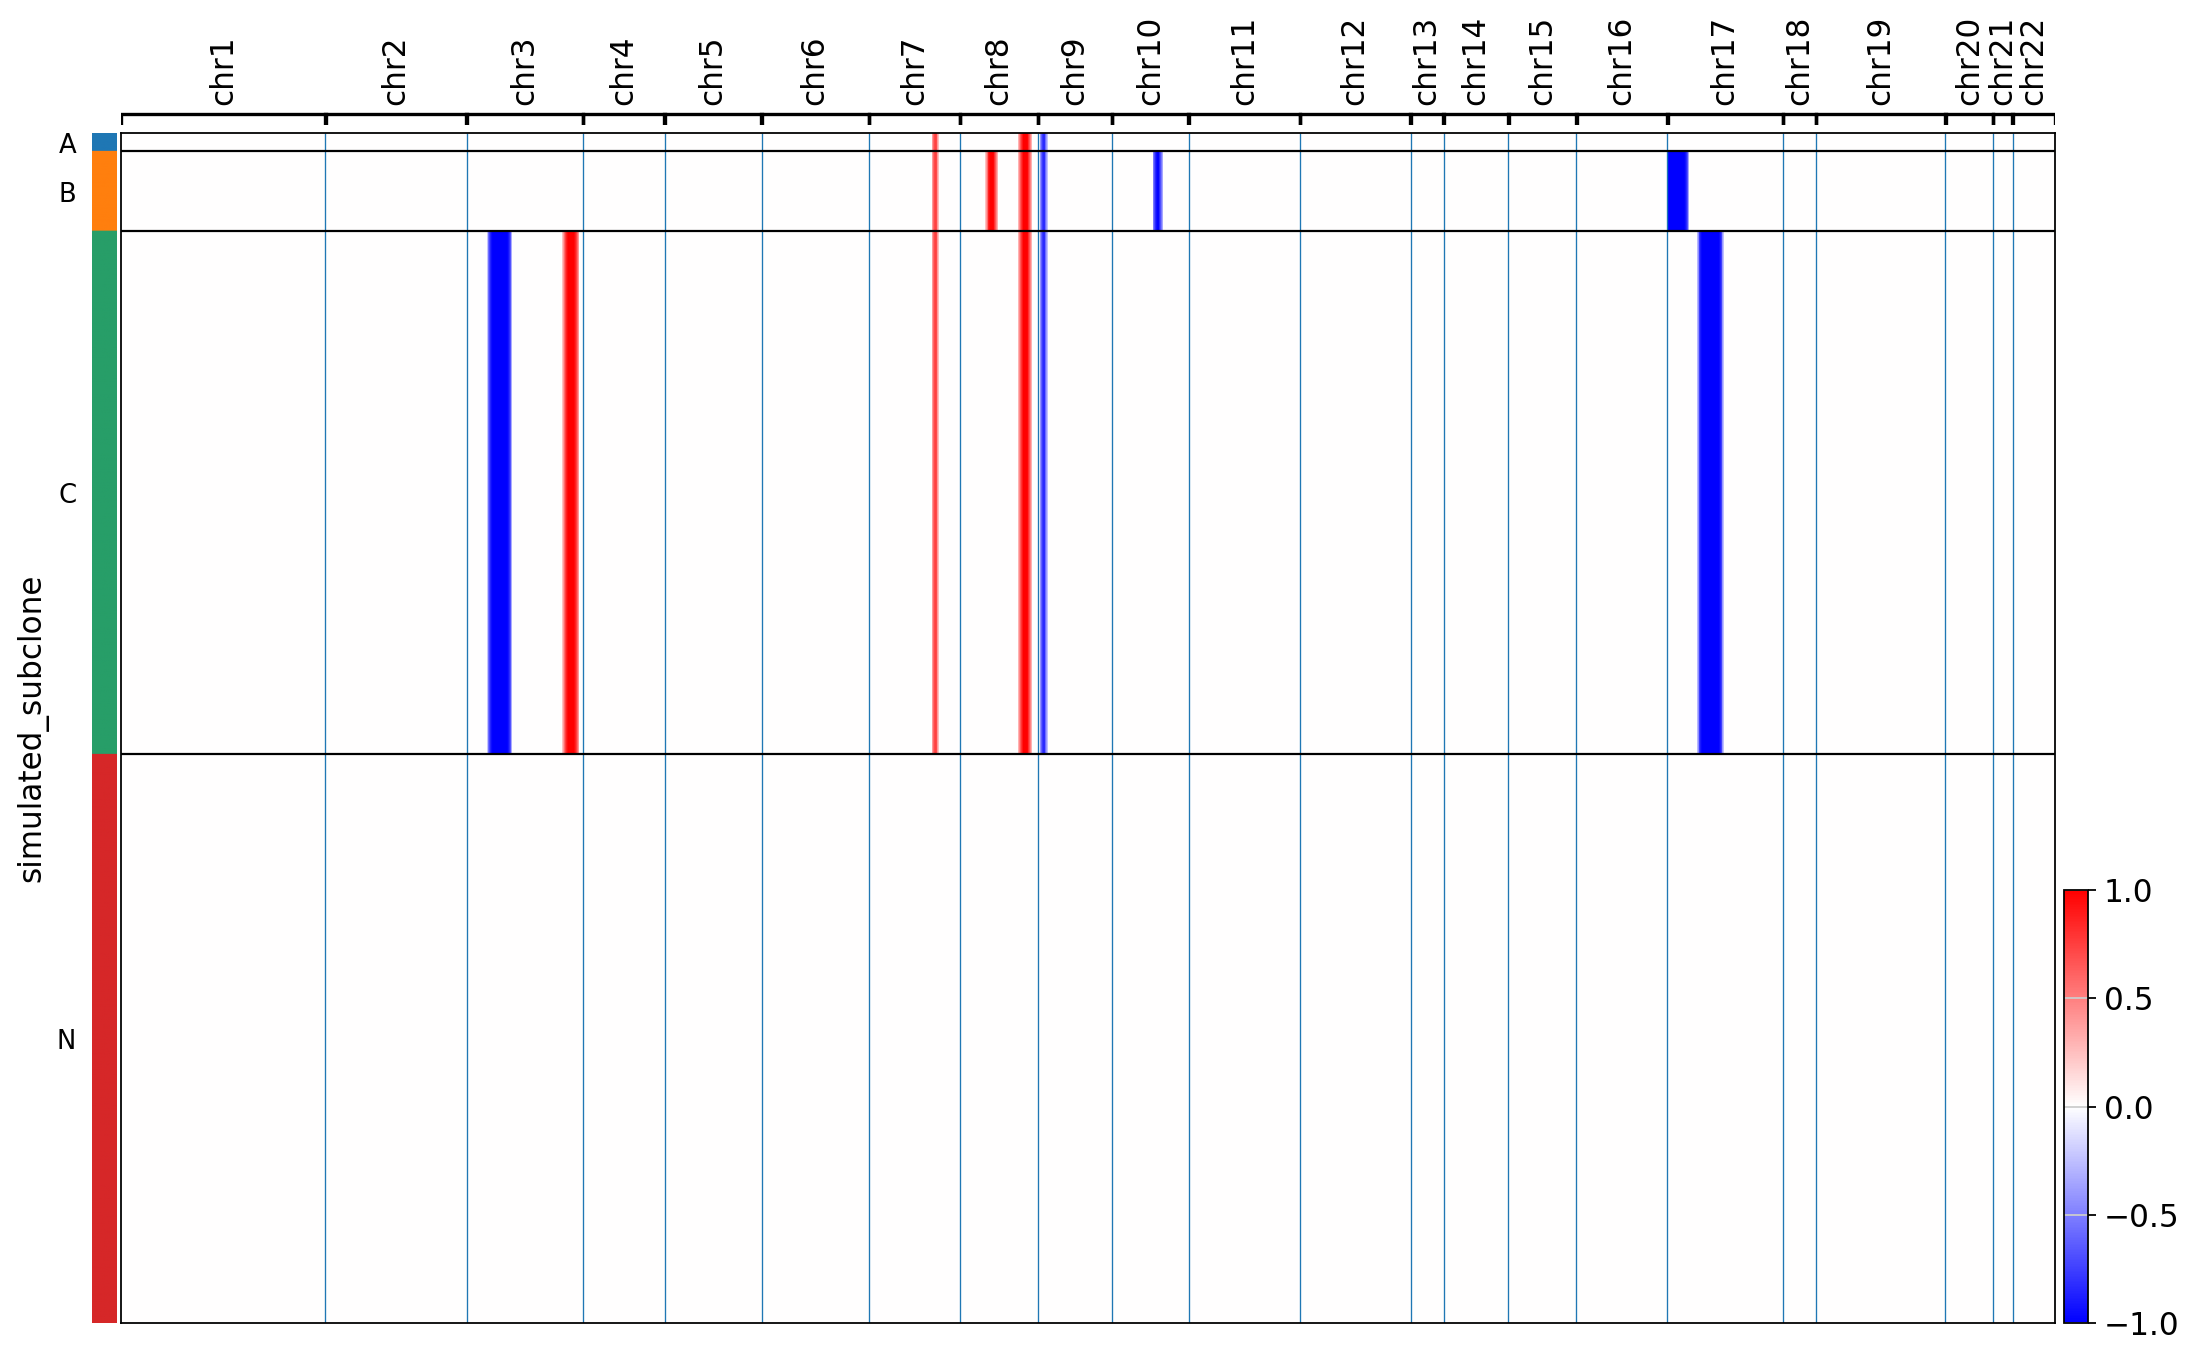

GT heatmap saved for T01


100%|██████████| 1/1 [00:02<00:00,  2.74s/it]


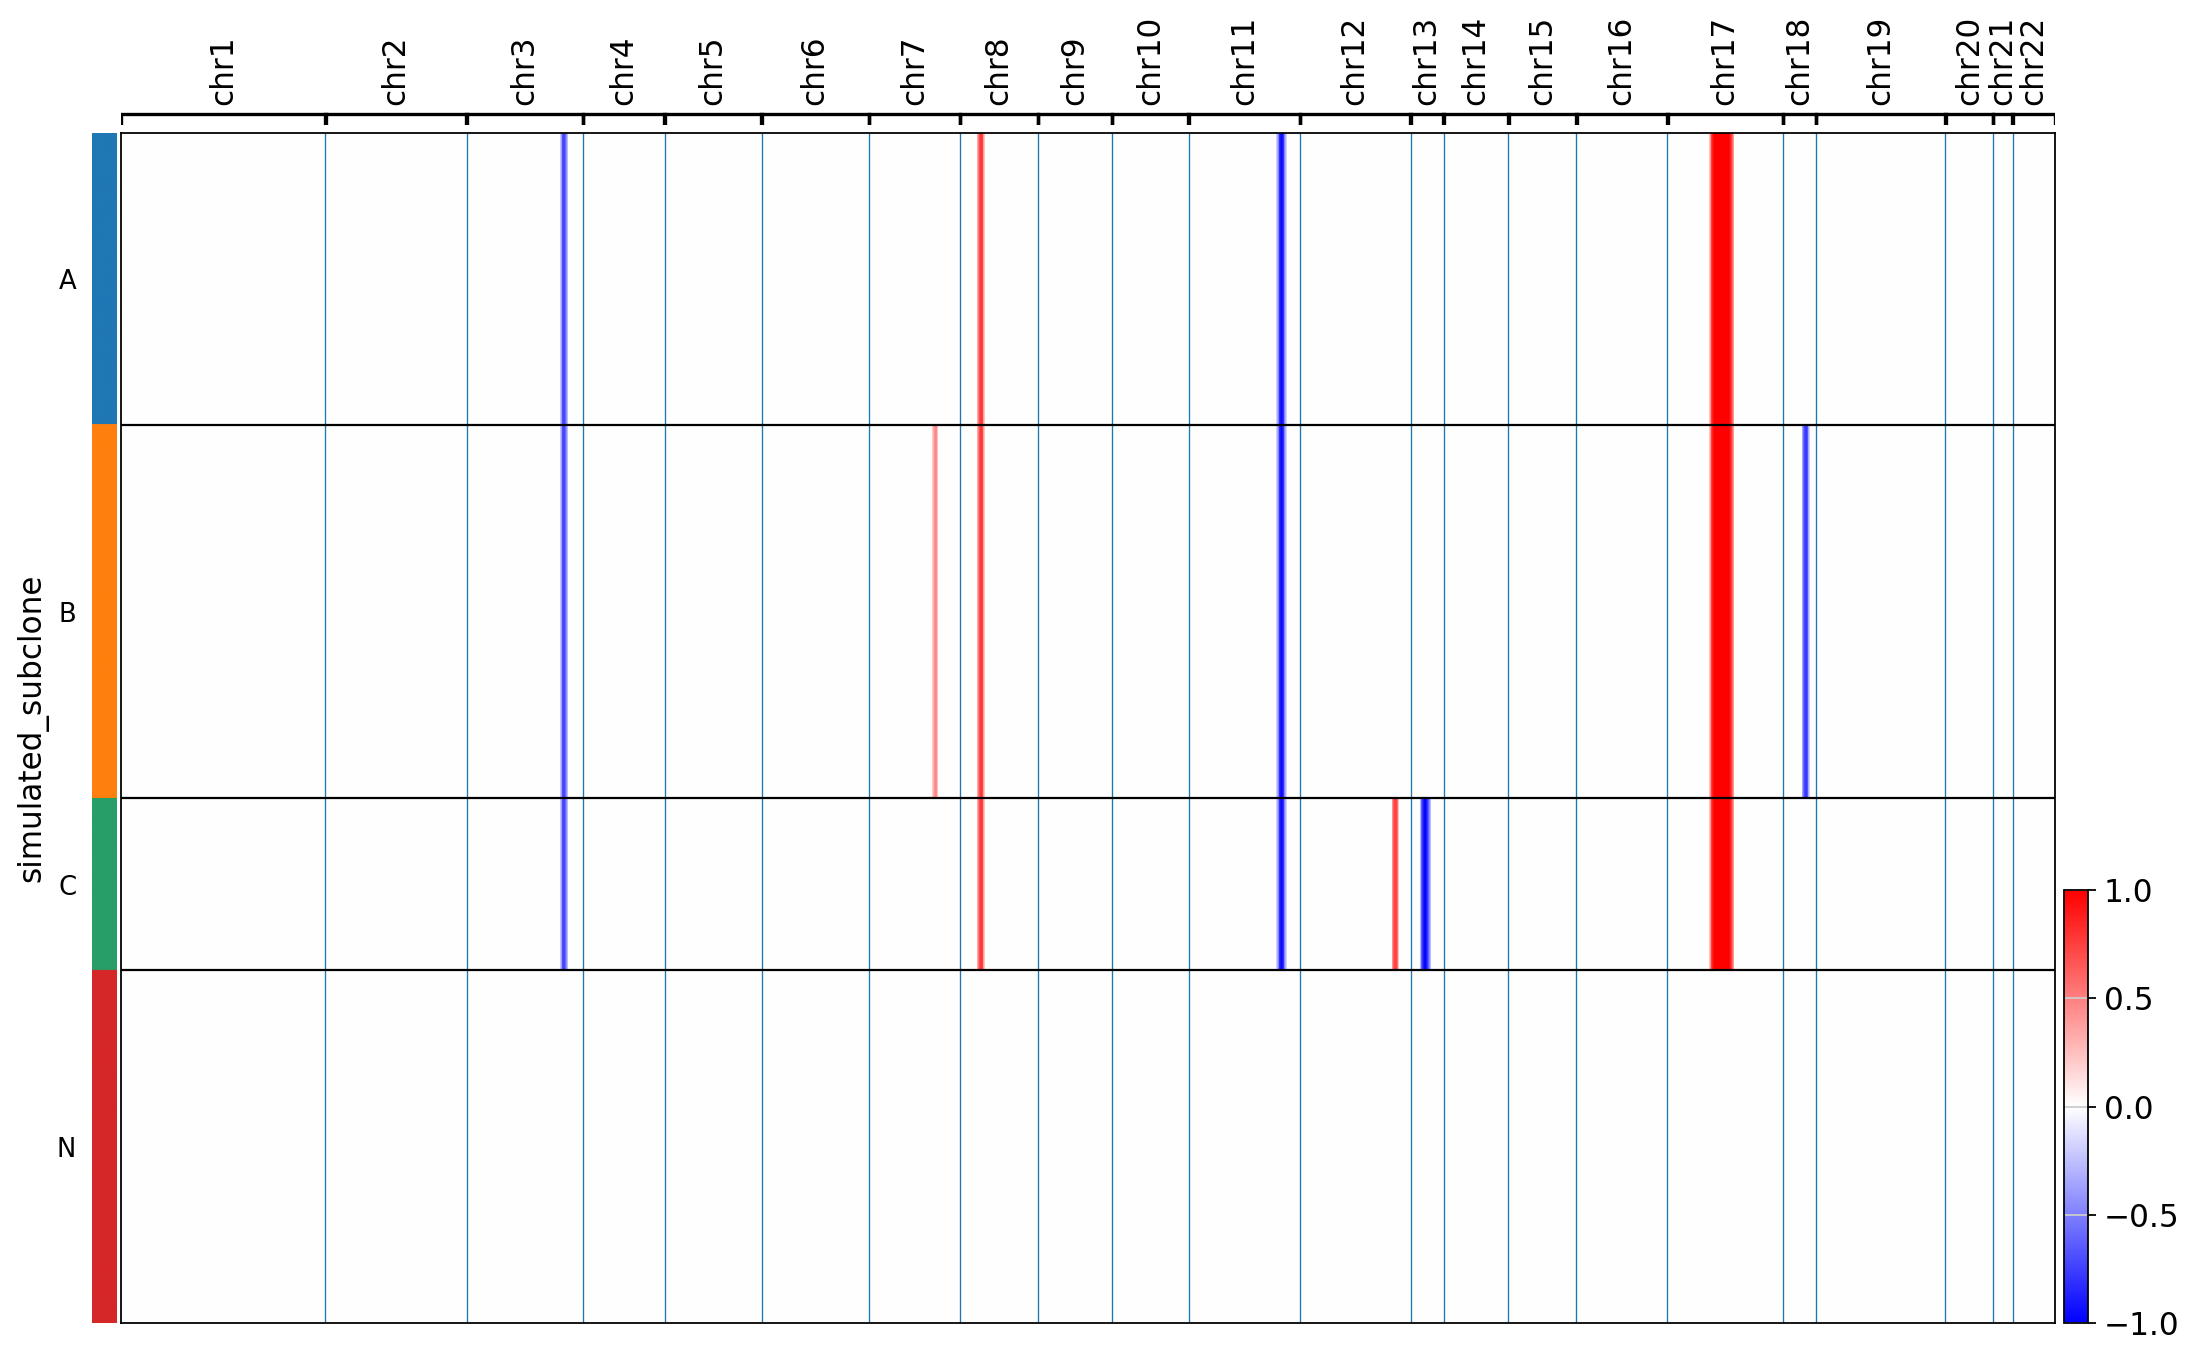

GT heatmap saved for T02


100%|██████████| 1/1 [00:02<00:00,  2.74s/it]


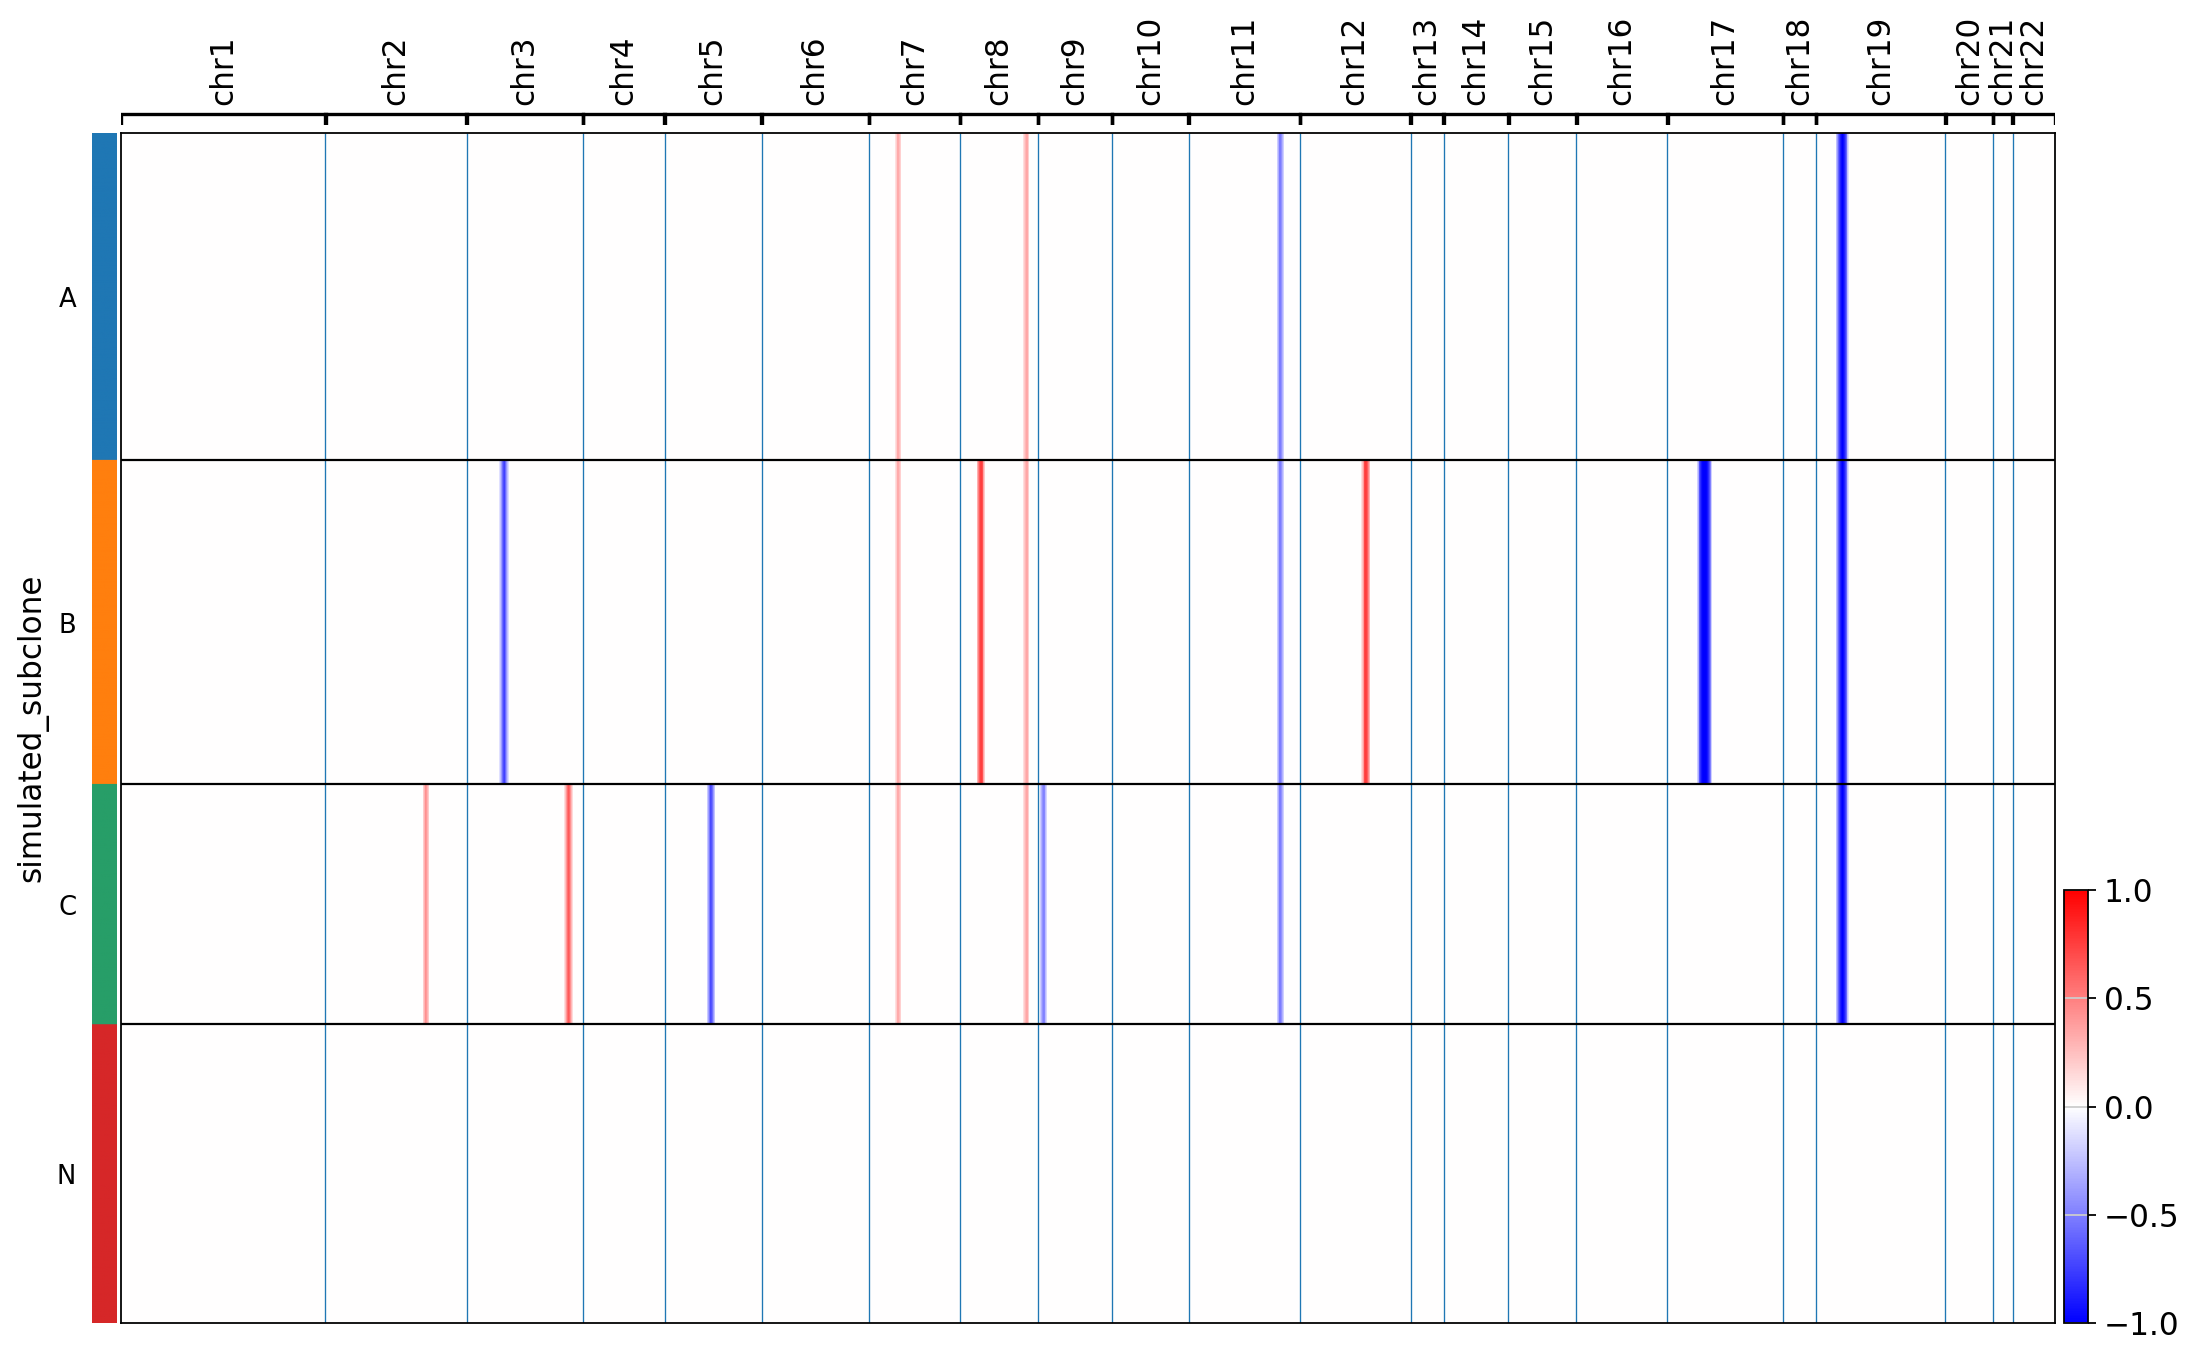

GT heatmap saved for T03


100%|██████████| 1/1 [00:02<00:00,  2.78s/it]


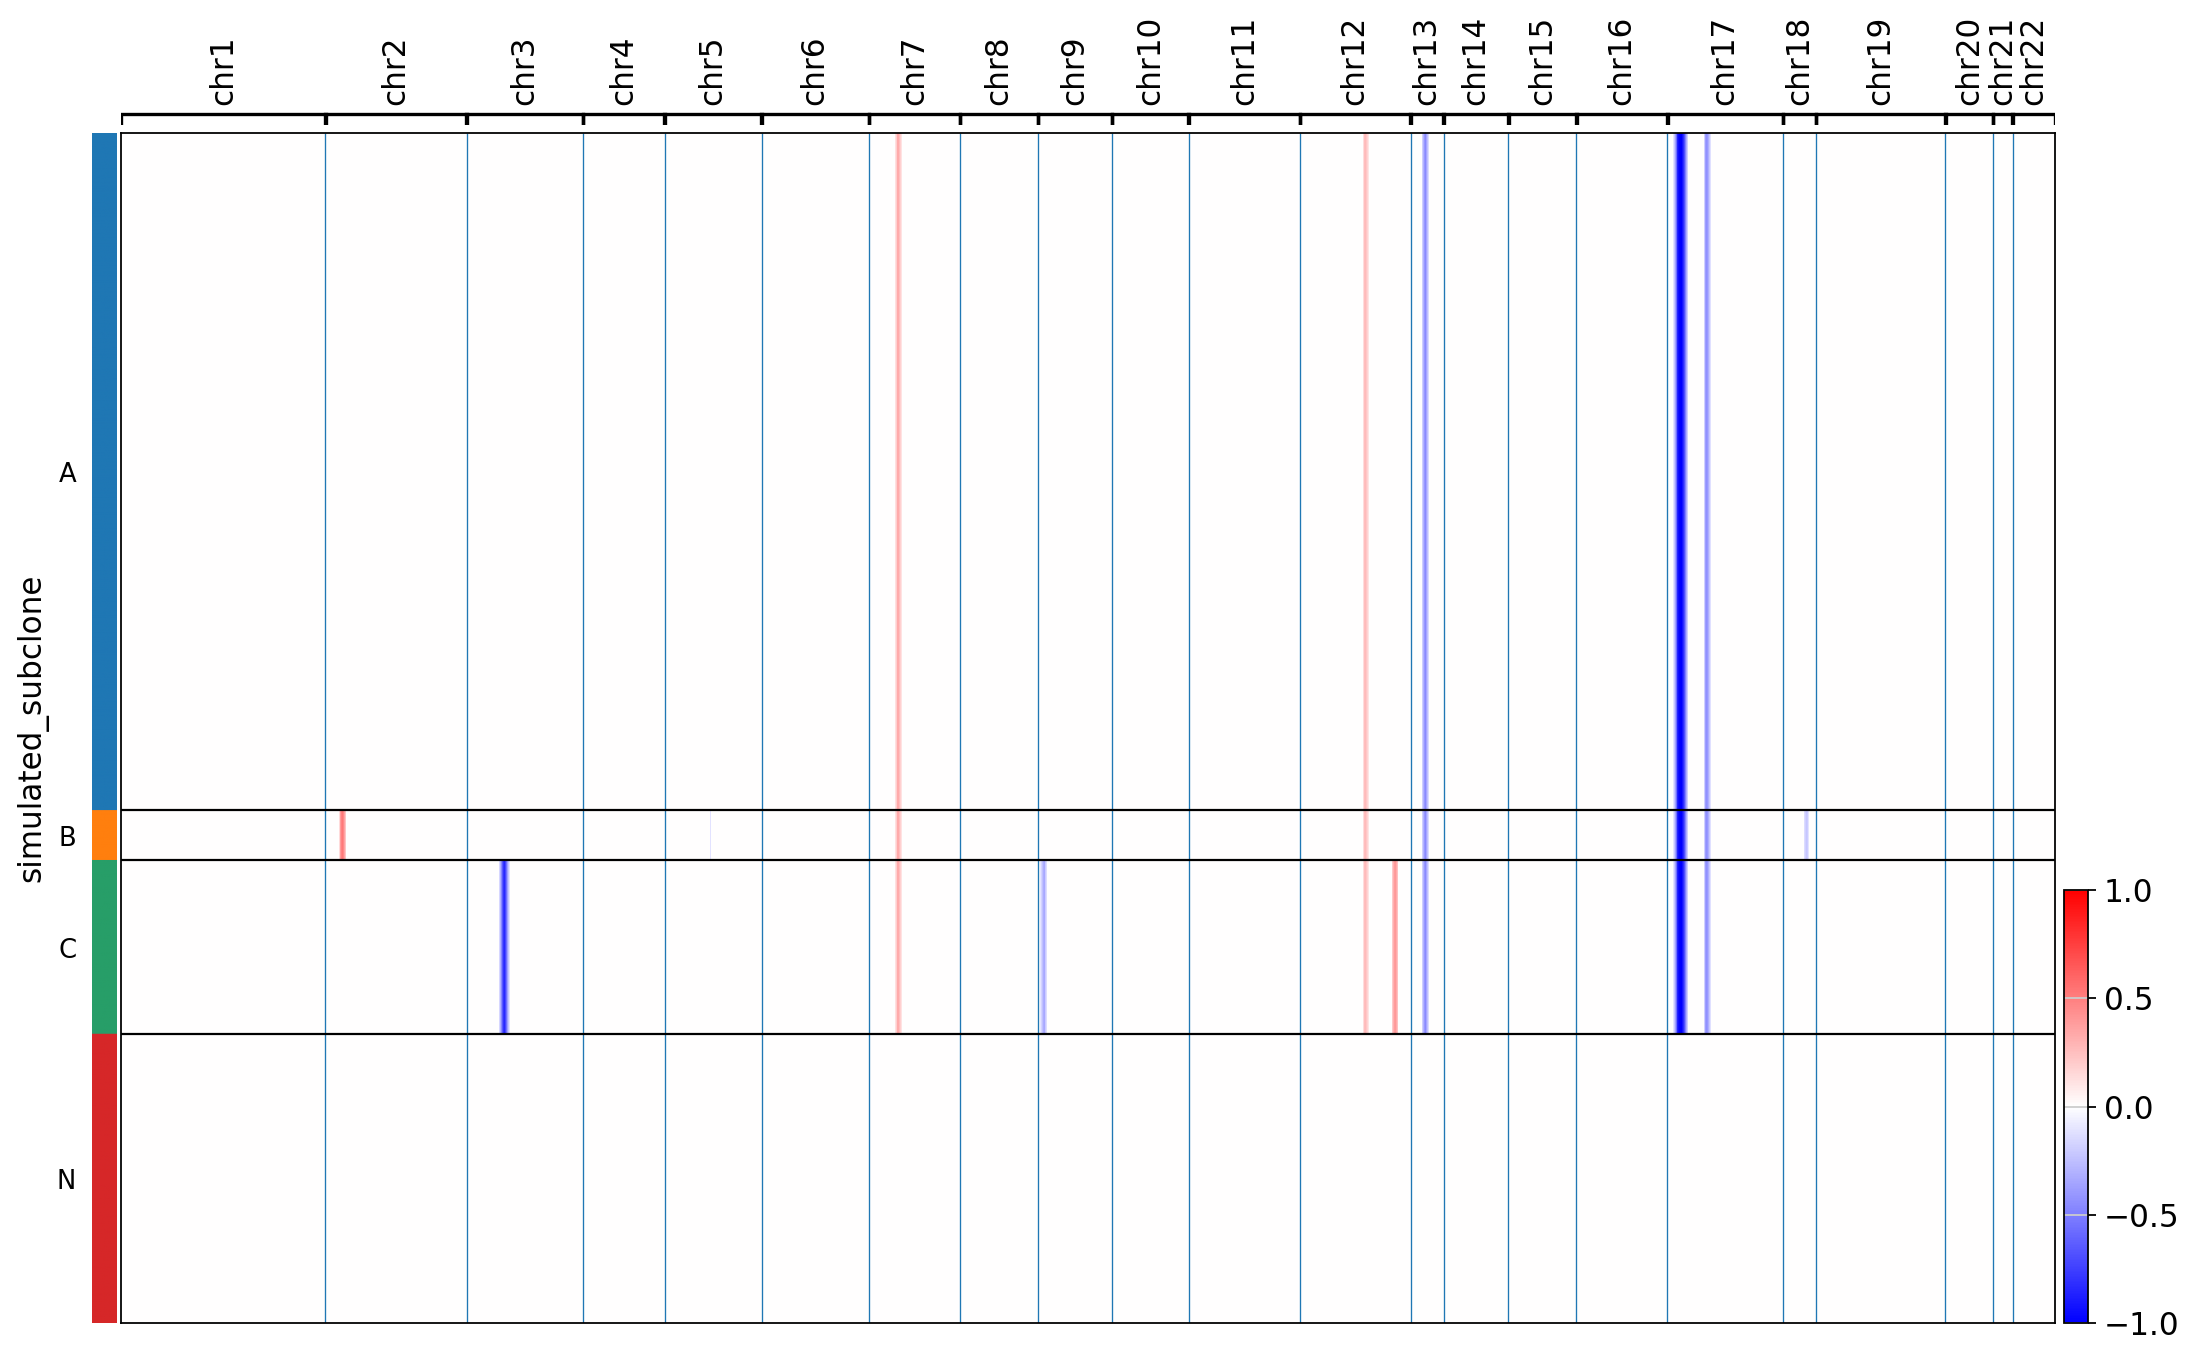

GT heatmap saved for T04


100%|██████████| 1/1 [00:02<00:00,  2.87s/it]


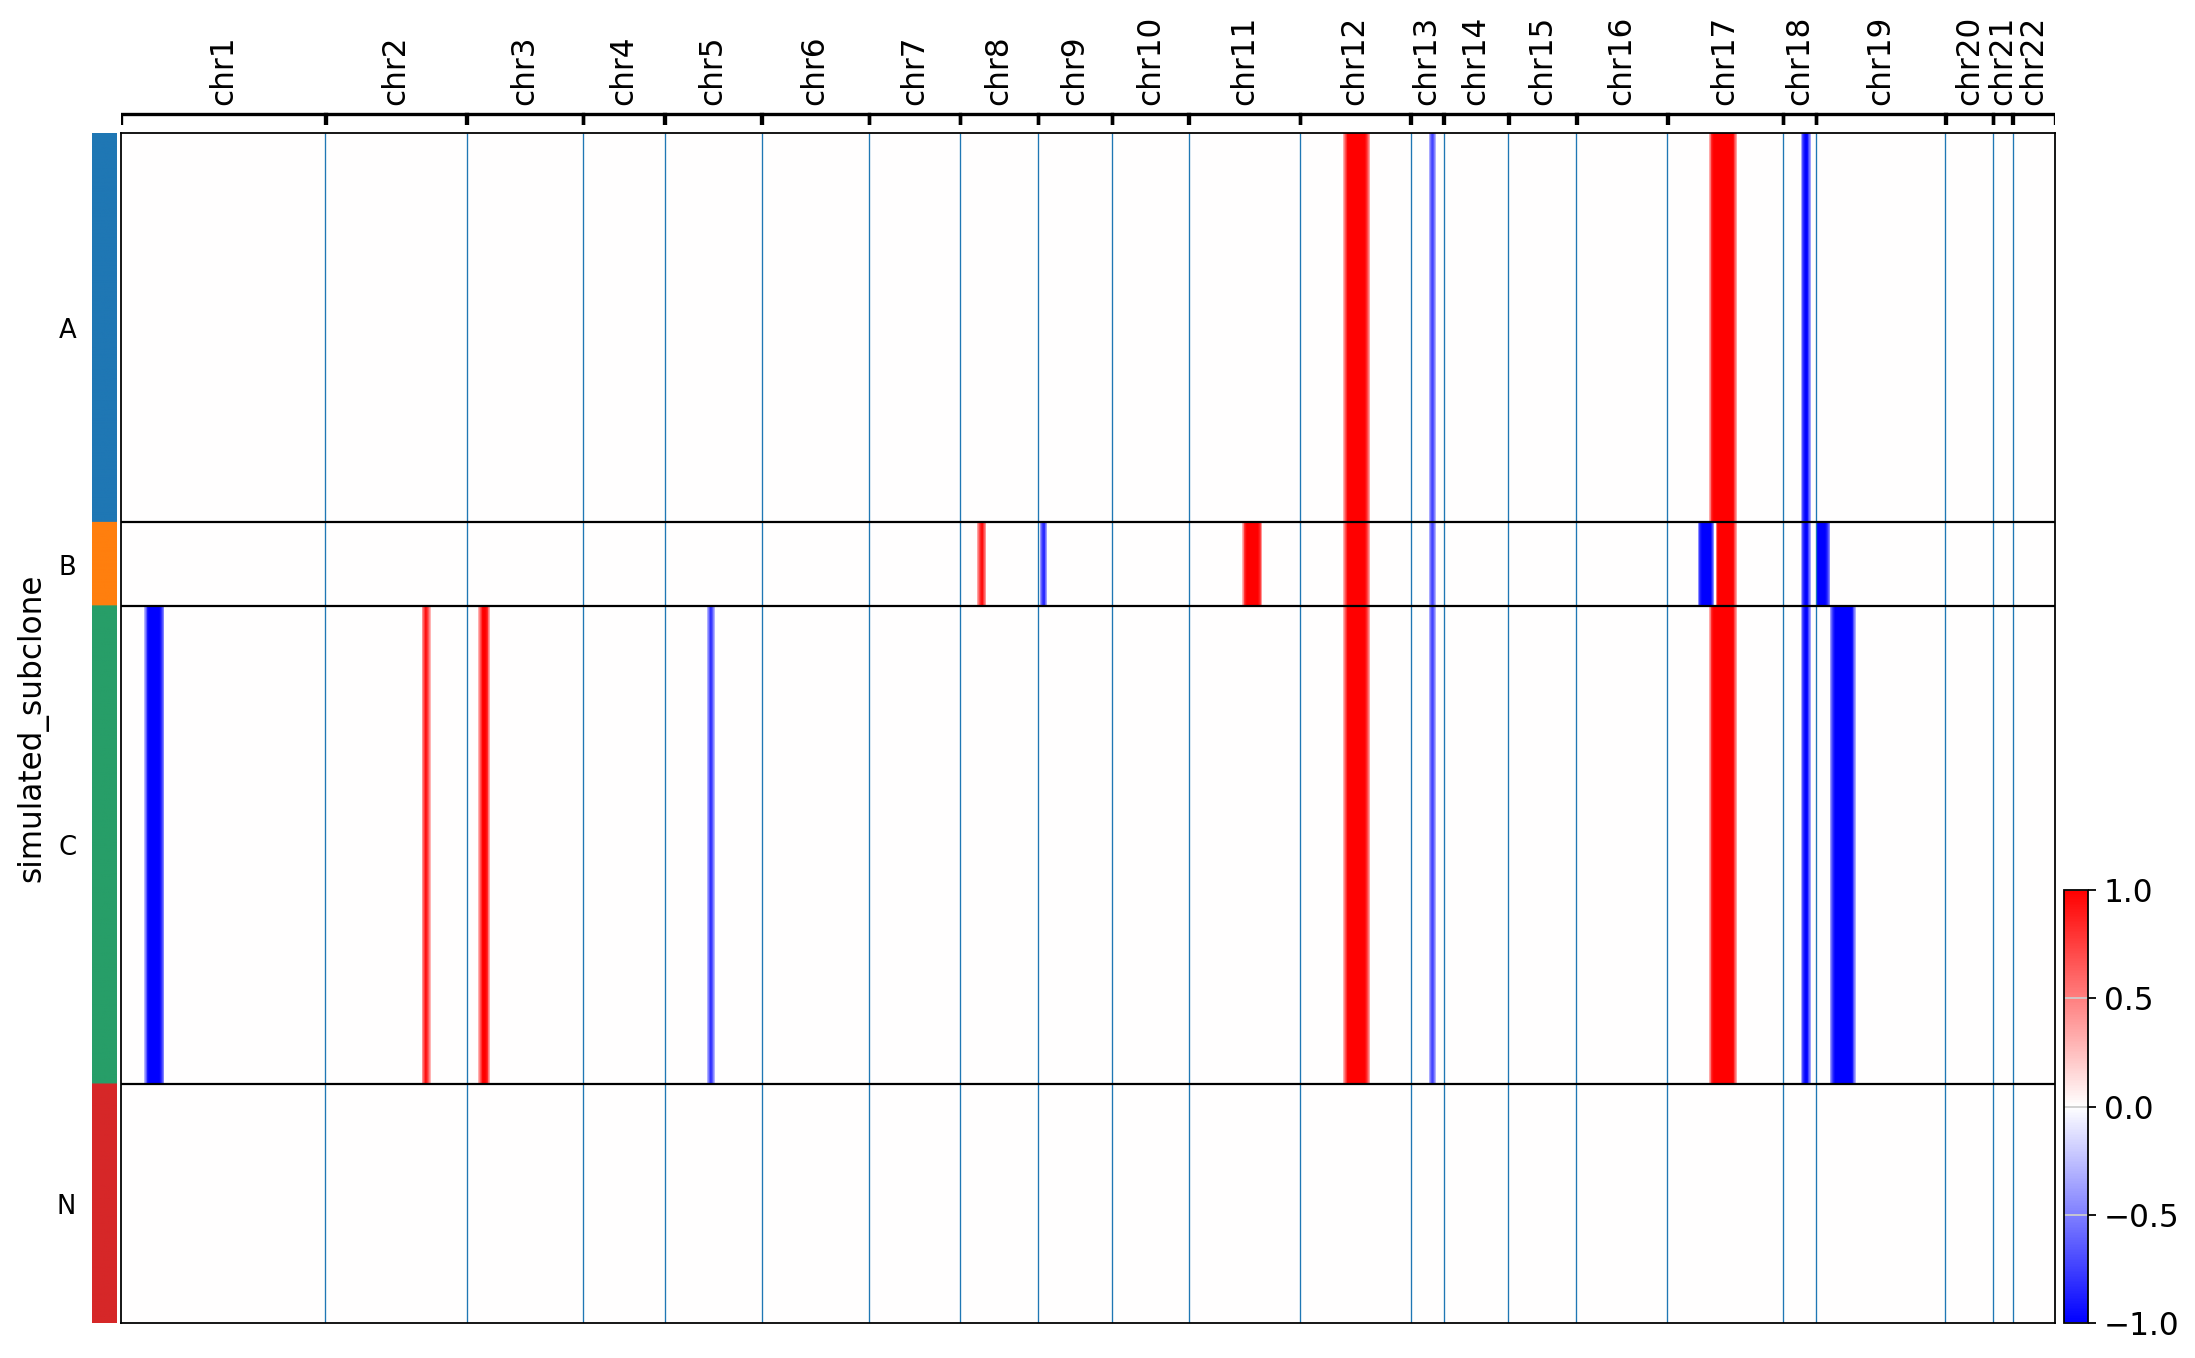

GT heatmap saved for T05


100%|██████████| 1/1 [00:02<00:00,  2.76s/it]


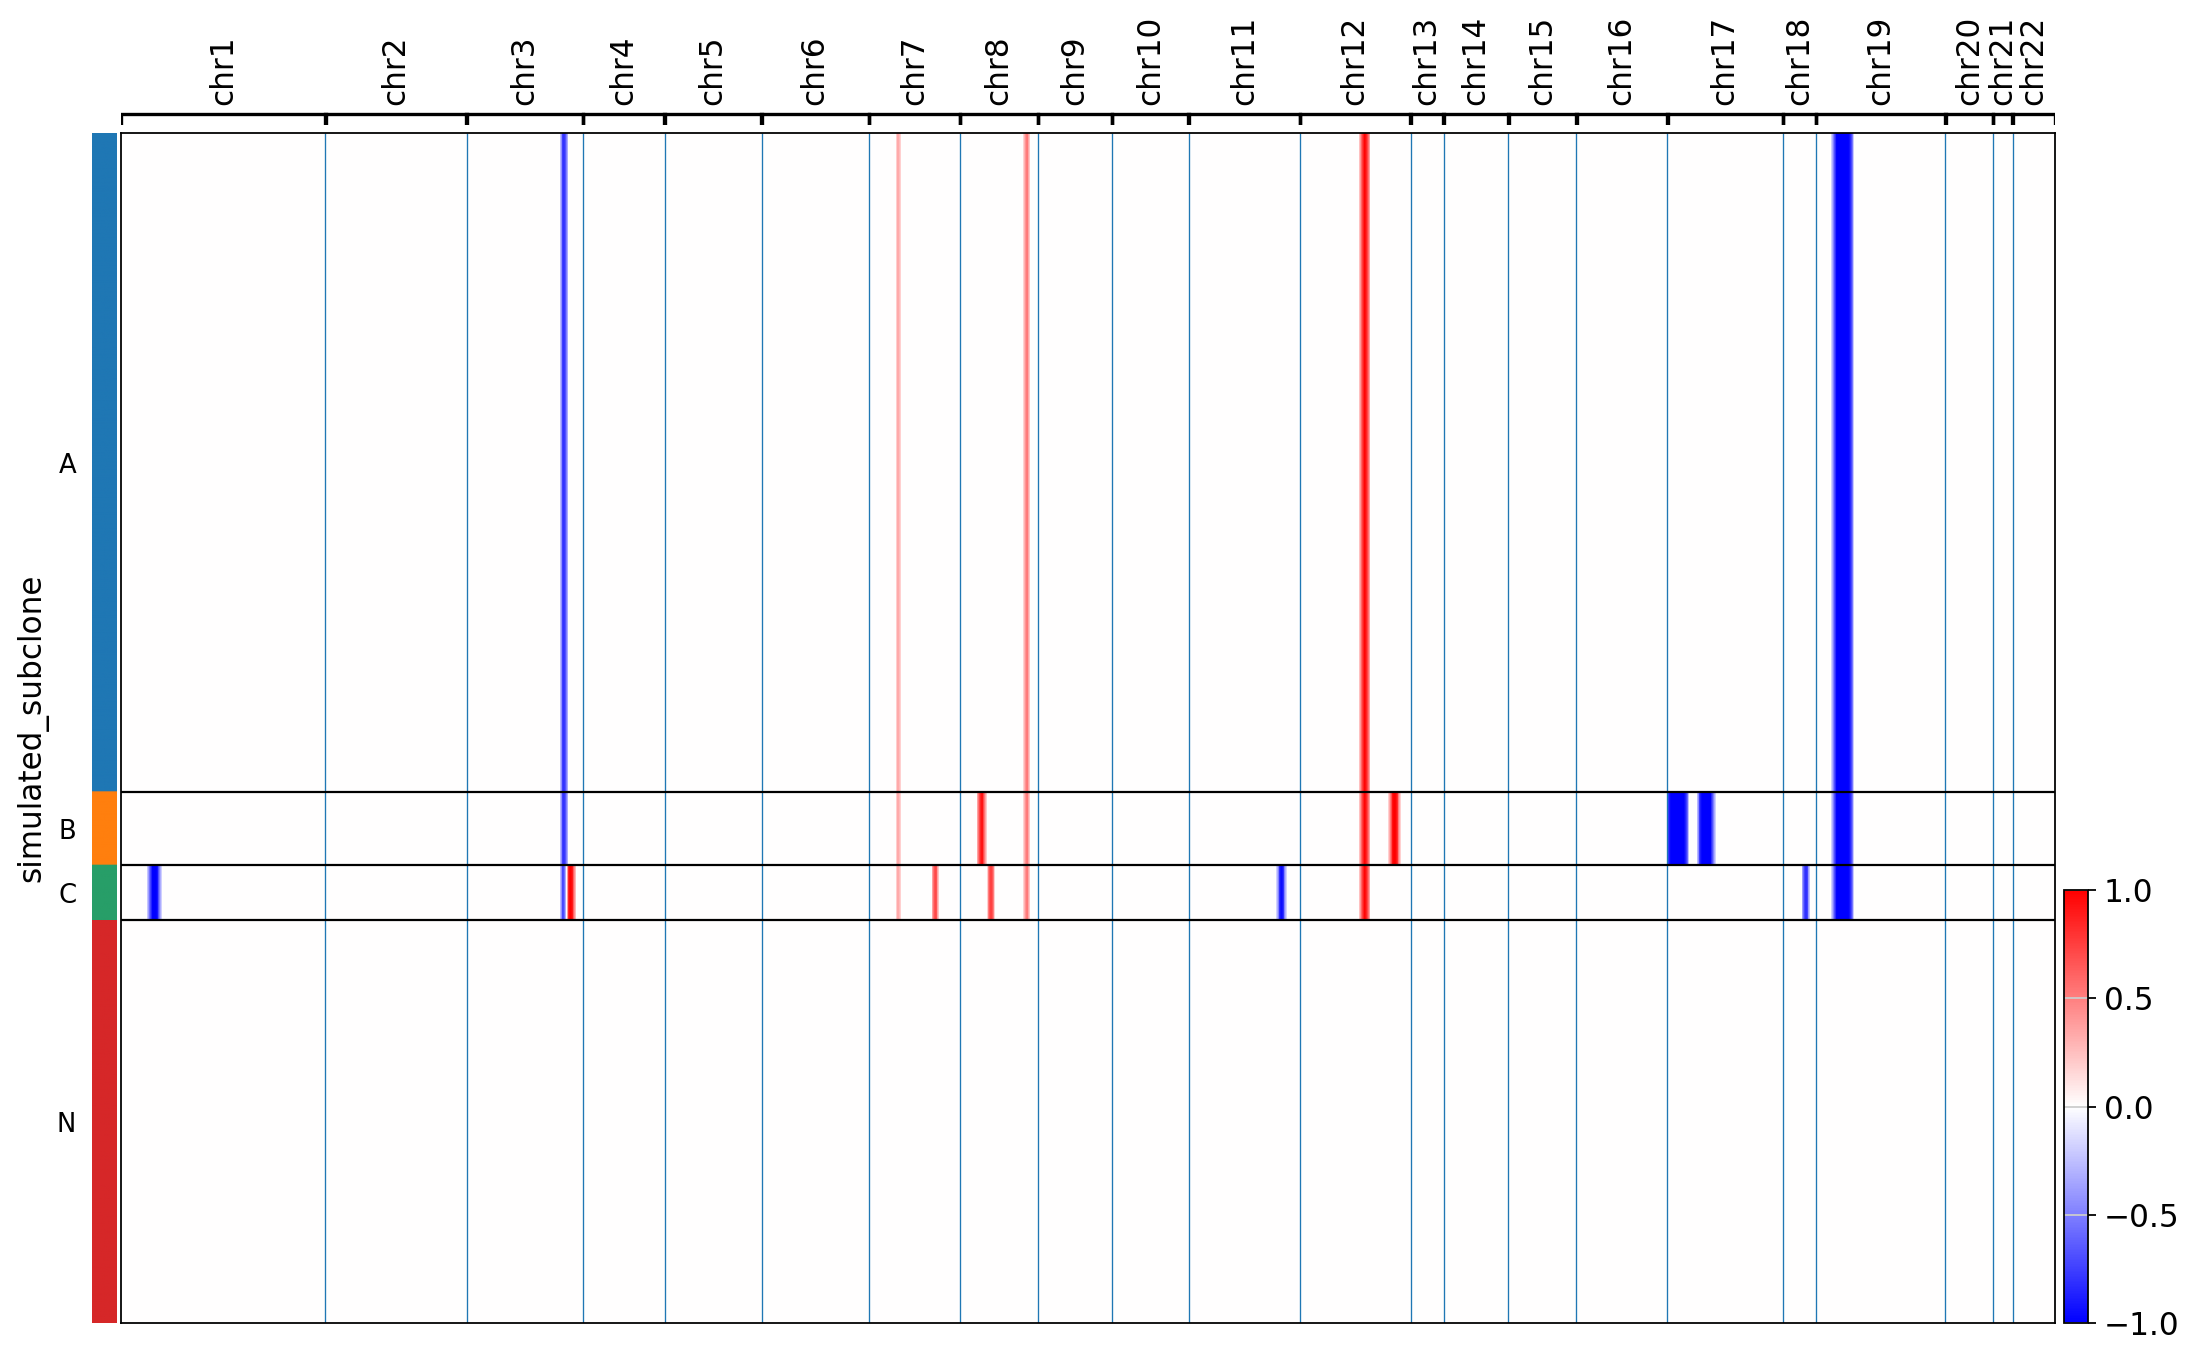

GT heatmap saved for T06


100%|██████████| 1/1 [00:02<00:00,  2.67s/it]


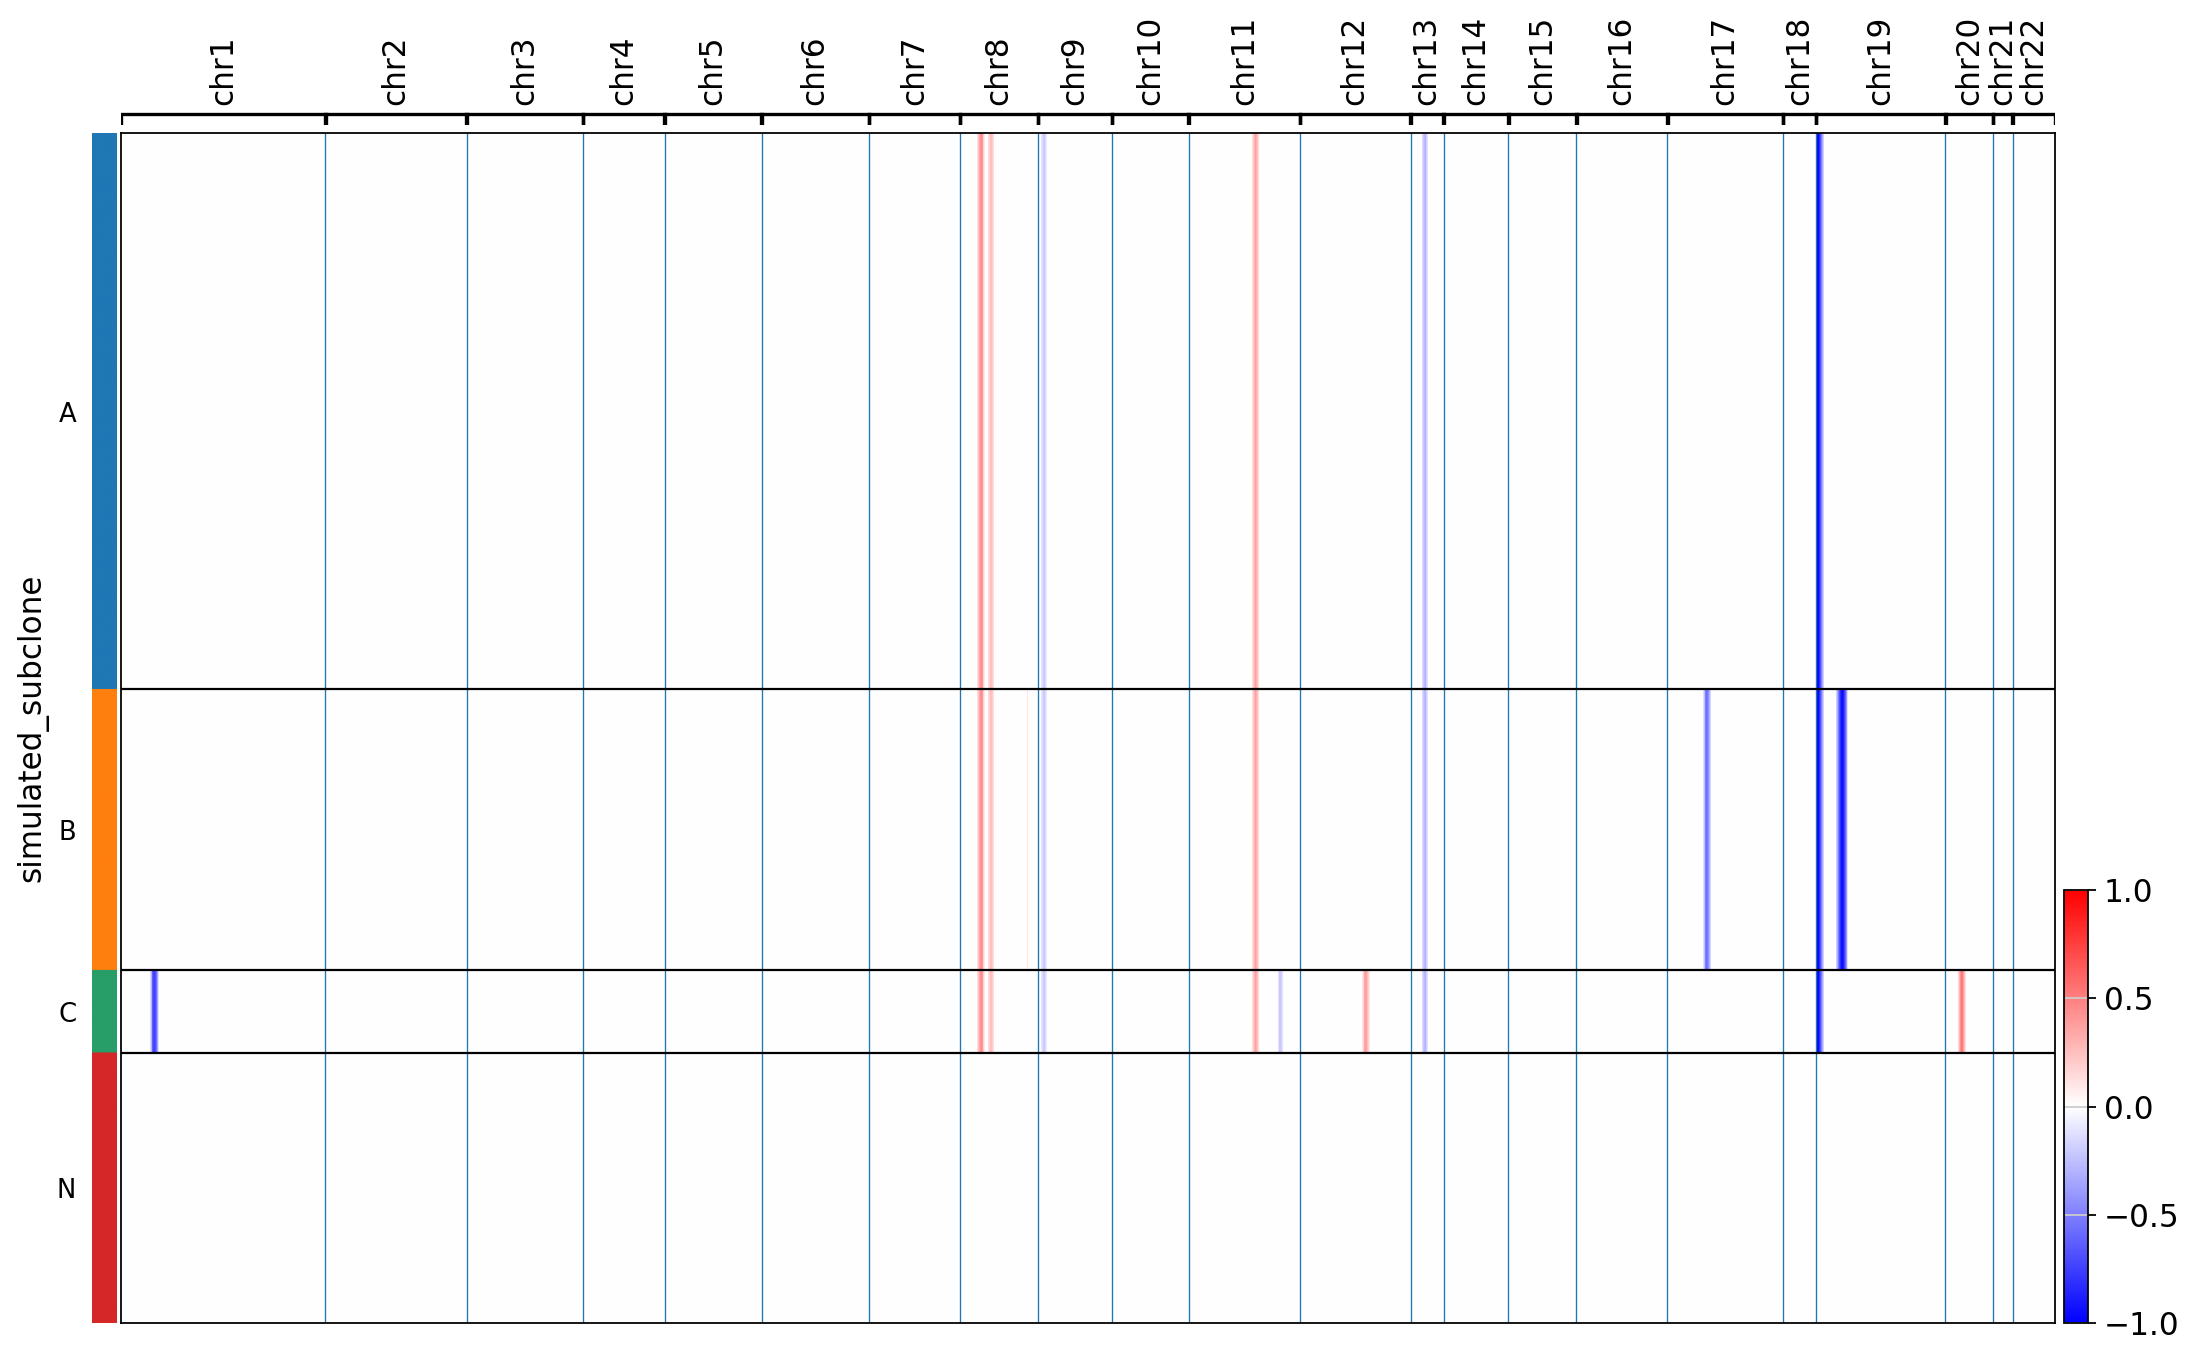

GT heatmap saved for T07


100%|██████████| 1/1 [00:02<00:00,  2.73s/it]


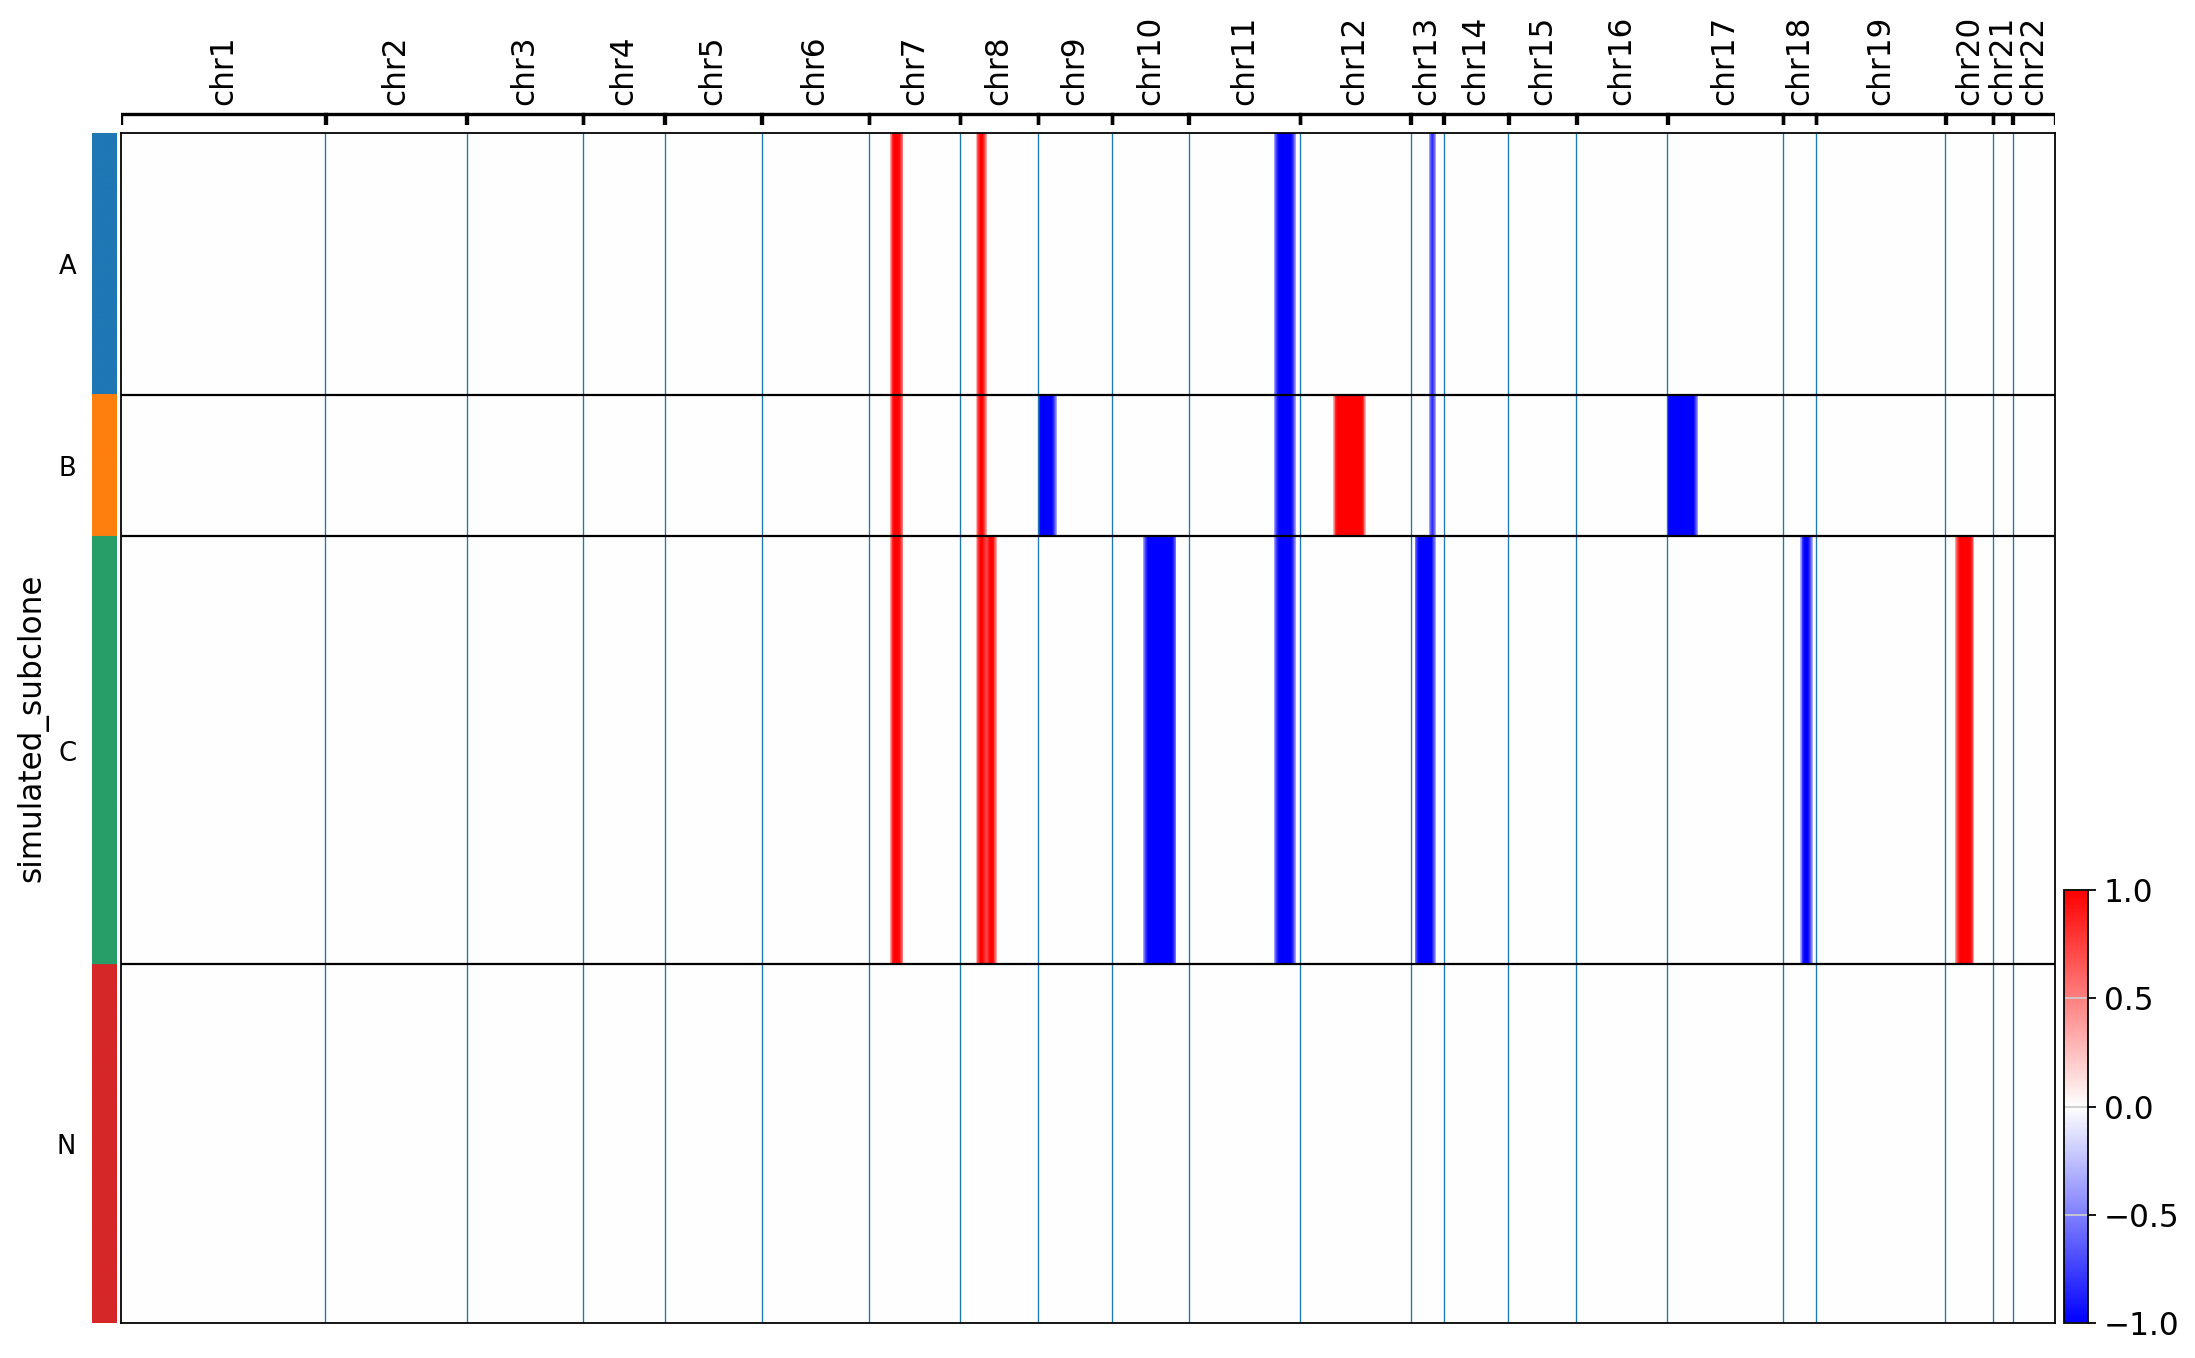

GT heatmap saved for T08


100%|██████████| 1/1 [00:02<00:00,  2.71s/it]


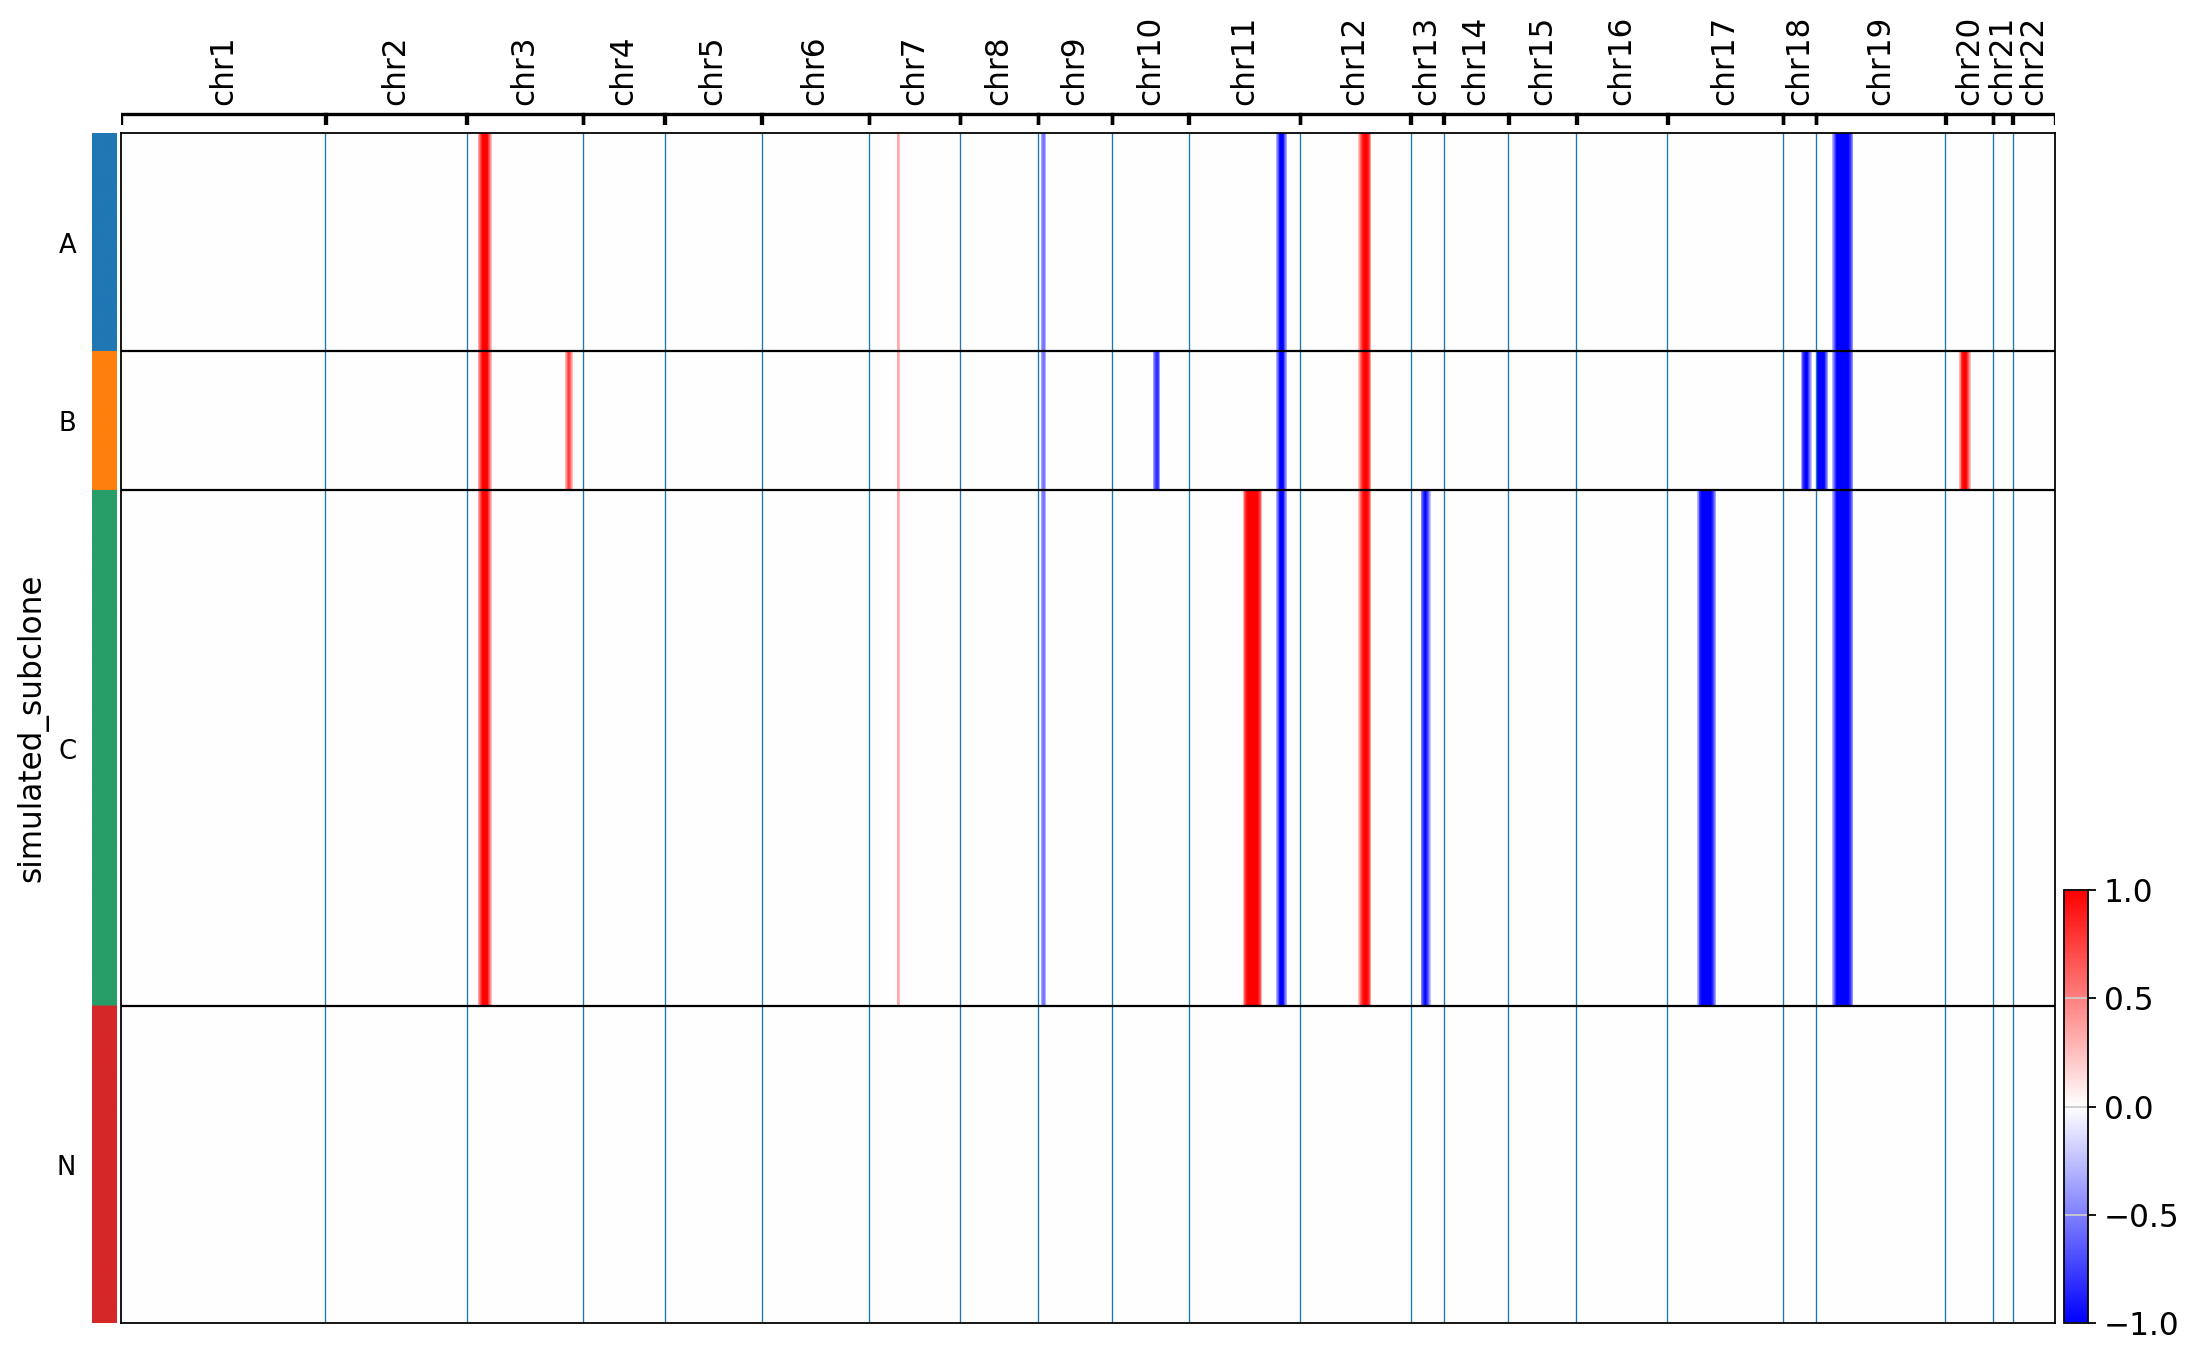

GT heatmap saved for T09


100%|██████████| 1/1 [00:02<00:00,  2.74s/it]


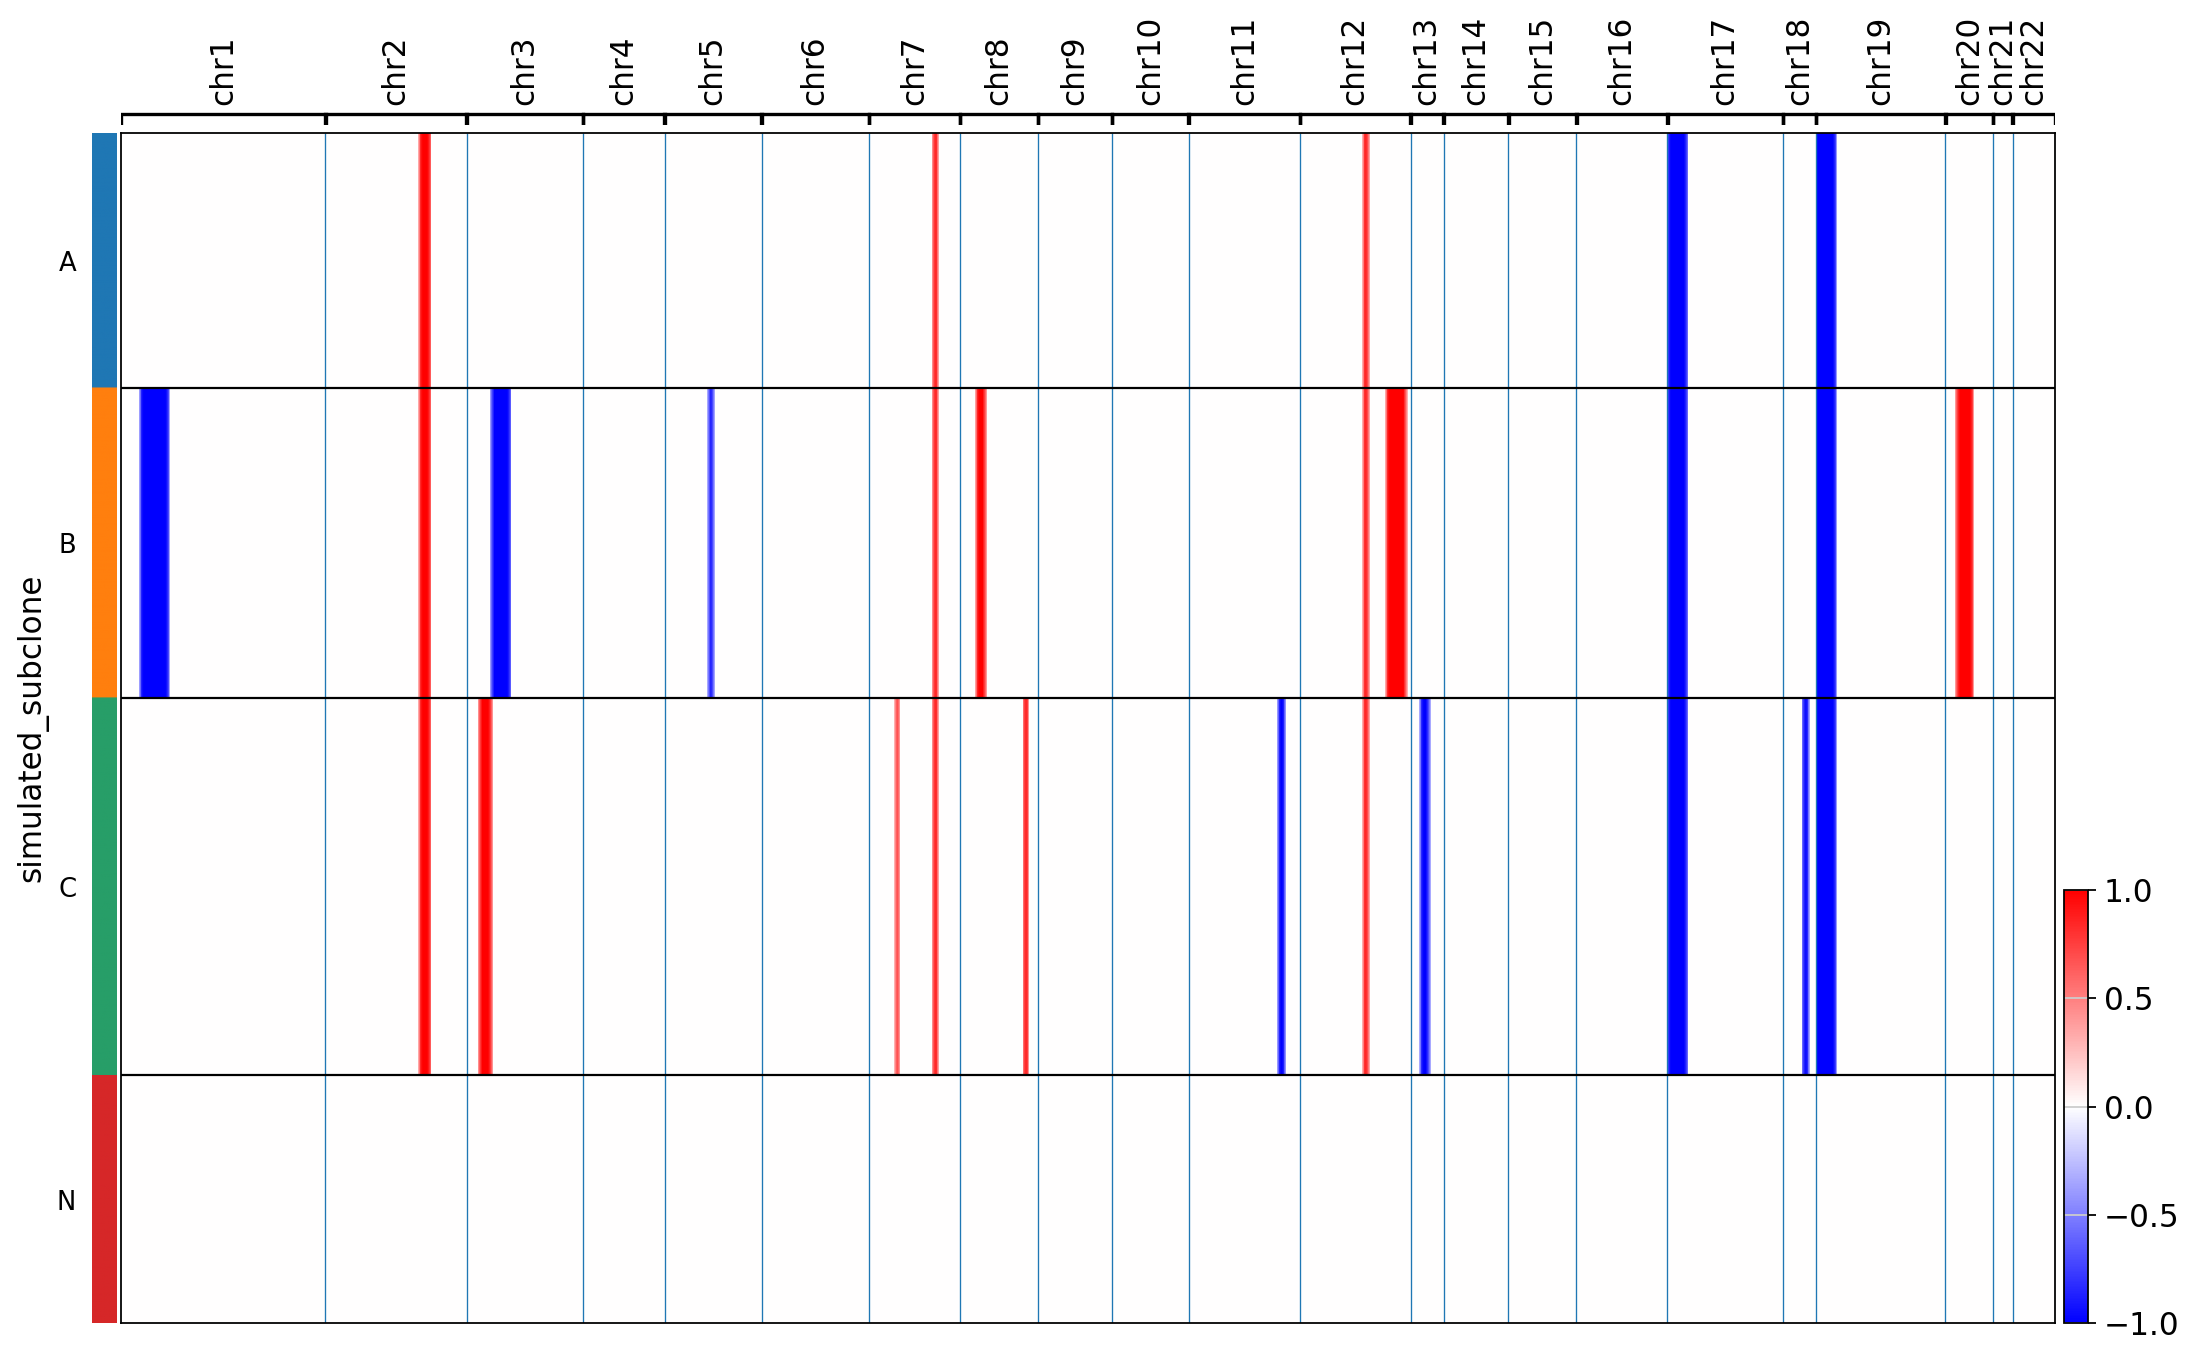

GT heatmap saved for T10
GT plots saved under: /home/augusta/storage3/augusta/insituCNV/InSituCNV/Evaluate_technical_constrains/results/plots/ground_truth


In [11]:
# Optional: plot GT heatmaps for all full template datasets generated above
PLOT_GT_HEATMAPS = True
OVERWRITE_GT_PLOTS = False

GT_PLOT_DIR = ROOT / "results" / "plots" / "ground_truth"
GT_PLOT_DIR.mkdir(parents=True, exist_ok=True)

if PLOT_GT_HEATMAPS:
    try:
        import infercnvpy as cnv
    except ImportError as e:
        raise ImportError("infercnvpy is required for GT heatmaps. Install it in this env before plotting.") from e

    old_figdir = sc.settings.figdir
    sc.settings.figdir = str(GT_PLOT_DIR)

    try:
        for r in summary_df.itertuples(index=False):
            template_id = r.template_id
            in_path = Path(r.output_h5ad)
            gt_png = GT_PLOT_DIR / f"chromosome_heatmap_GT_{template_id}.svg"

            if not in_path.exists():
                print(f"SKIP {template_id}: missing {in_path}")
                continue
            if gt_png.exists() and not OVERWRITE_GT_PLOTS:
                print(f"SKIP {template_id}: GT plot exists")
                continue

            try:
                ad = sc.read_h5ad(in_path)
                if "CNV_GT" not in ad.layers:
                    print(f"SKIP {template_id}: CNV_GT layer missing")
                    continue
                if "simulated_subclone" not in ad.obs.columns:
                    print(f"SKIP {template_id}: simulated_subclone missing in obs")
                    continue

                ad.X = ad.layers["CNV_GT"].copy()
                ref_key = defaults["cell_type_reference_key"]
                cnv_types = defaults["cell_type_cnv"] if isinstance(defaults["cell_type_cnv"], list) else [defaults["cell_type_cnv"]]
                all_types = [str(x) for x in ad.obs[ref_key].dropna().unique()]
                reference_cats = [ct for ct in all_types if ct not in cnv_types]
                if len(reference_cats) == 0:
                    print(f"SKIP {template_id}: no reference categories found (all in cell_type_cnv)")
                    continue

                cnv.tl.infercnv(
                    ad,
                    reference_key=ref_key,
                    reference_cat=reference_cats,
                )

                cnv.pl.chromosome_heatmap(
                    ad,
                    groupby="simulated_subclone",
                    dendrogram=False,
                    vmin=-1,
                    vmax=1,
                    save=f"_GT_{template_id}.png",
                )
                print(f"GT heatmap saved for {template_id}")
            except Exception as e:
                print(f"FAILED GT plot {template_id}: {e}")
    finally:
        sc.settings.figdir = old_figdir

    print(f"GT plots saved under: {GT_PLOT_DIR}")
